In [1]:
# ==============================================================================
# Lab 5: Model Development — PlantCLEF Provider Classification
# วิชา 01076251 Machine Learning for Data Science
# สมาชิกกลุ่ม:
# 1. ปิยังกูร ปัสสาวะกัง (6810405691)
# 2. ศิวภูมิ พรหมจรรย์ (6810405887)
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.pipeline import make_pipeline as make_imblearn_pipeline
from imblearn.over_sampling import RandomOverSampler

# ตั้งค่า Seed สำหรับ Reproducibility
RANDOM_STATE = 42

In [2]:
# 1. โหลด DINOv2 Embeddings
X_train = np.load('./X_train_dinov2.npy')
X_val = np.load('./X_val_dinov2.npy')

# 2. โหลด Metadata ของภาพพืช
i_train = pd.read_parquet('./i_train.parquet')
i_val = pd.read_parquet('./i_val.parquet')

# ดึง Target Label (provider)
y_train_raw = i_train['provider']
y_val_raw = i_val['provider']

# Encode Label เป็นตัวเลข (0-4)
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_val = label_encoder.transform(y_val_raw)

print("=== Data Dimensions ===")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape} | y_val shape:   {y_val.shape}")
print("\nClasses Mapping:")
for idx, name in enumerate(label_encoder.classes_):
    print(f"  Class {idx}: {name}")

=== Data Dimensions ===
X_train shape: (1472, 384) | y_train shape: (1472,)
X_val shape:   (316, 384) | y_val shape:   (316,)

Classes Mapping:
  Class 0: CBN
  Class 1: GUARDEN
  Class 2: LISAH
  Class 3: OPTMix
  Class 4: RNNB


In [3]:
# Baseline Logistic Regression
baseline_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline_model.fit(X_train, y_train)

train_acc = baseline_model.score(X_train, y_train)
val_acc = baseline_model.score(X_val, y_val)

print("=== 1. Baseline Model Performance ===")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Val Accuracy:   {val_acc:.4f}")

=== 1. Baseline Model Performance ===
Train Accuracy: 1.0000
Val Accuracy:   0.9778


In [4]:
# ใช้ Pipeline จัดการ Imbalanced Class ร่วมกับ Classifier
os_pipeline = make_imblearn_pipeline(
    RandomOverSampler(random_state=RANDOM_STATE),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)

os_pipeline.fit(X_train, y_train)
y_pred_os = os_pipeline.predict(X_val)

print("=== 2. OverSampled Logistic Regression Performance ===")
print(f"Val Accuracy: {accuracy_score(y_val, y_pred_os):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_os, target_names=label_encoder.classes_))

=== 2. OverSampled Logistic Regression Performance ===
Val Accuracy: 0.9715

Classification Report:
              precision    recall  f1-score   support

         CBN       1.00      1.00      1.00       221
     GUARDEN       0.87      0.90      0.89        30
       LISAH       0.97      0.88      0.92        32
      OPTMix       0.92      0.92      0.92        12
        RNNB       0.87      0.95      0.91        21

    accuracy                           0.97       316
   macro avg       0.92      0.93      0.93       316
weighted avg       0.97      0.97      0.97       316



In [5]:
# ตั้งค่า Hyperparameter Grid สำหรับ Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE)
grid_search = GridSearchCV(rf_base, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("=== 3. Random Forest Hyperparameter Tuning ===")
print("Best Parameters:", grid_search.best_params_)
print(f"Best CV Score:    {grid_search.best_score_:.4f}")
print(f"Validation Score: {best_rf.score(X_val, y_val):.4f}")

=== 3. Random Forest Hyperparameter Tuning ===
Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score:    0.9368
Validation Score: 0.9335


In [6]:
clf_lr = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
clf_ridge = RidgeClassifier(alpha=1.0, random_state=RANDOM_STATE)
clf_rf = best_rf

ensemble_model = VotingClassifier(
    estimators=[
        ('lr', clf_lr),
        ('ridge', clf_ridge),
        ('rf', clf_rf)
    ],
    voting='hard'
)

ensemble_model.fit(X_train, y_train)
y_pred_ensemble = ensemble_model.predict(X_val)

print("=== 4. Voting Classifier Ensemble Performance ===")
print(f"Ensemble Val Accuracy: {accuracy_score(y_val, y_pred_ensemble):.4f}")

=== 4. Voting Classifier Ensemble Performance ===
Ensemble Val Accuracy: 0.9810


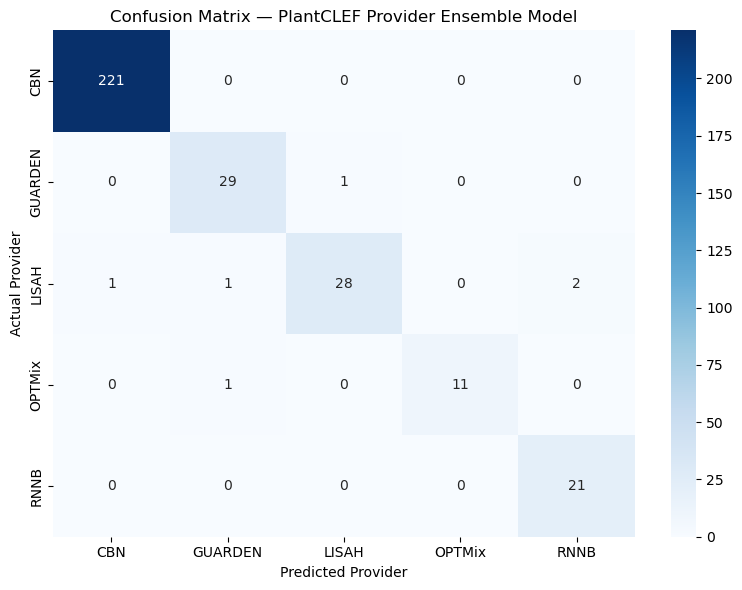

In [7]:
# สร้าง Confusion Matrix
cm = confusion_matrix(y_val, y_pred_ensemble)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=label_encoder.classes_, 
    yticklabels=label_encoder.classes_
)
plt.title('Confusion Matrix — PlantCLEF Provider Ensemble Model')
plt.xlabel('Predicted Provider')
plt.ylabel('Actual Provider')
plt.tight_layout()
plt.show()

In [8]:
# 1. บันทึกโมเดลและ Encoder
artifacts = {
    'model': ensemble_model,
    'label_encoder': label_encoder
}
joblib.dump(artifacts, 'plantclef_provider_model.joblib')
print(" Saved model artifacts to 'plantclef_provider_model.joblib'")

# 2. ทดลองโหลดกลับมาทำนายผล
loaded_artifacts = joblib.load('plantclef_provider_model.joblib')
loaded_model = loaded_artifacts['model']
loaded_encoder = loaded_artifacts['label_encoder']

# ทำนาย 5 ตัวอย่างแรกของ Val Set
sample_preds = loaded_model.predict(X_val[:5])
sample_pred_names = loaded_encoder.inverse_transform(sample_preds)
sample_actual_names = loaded_encoder.inverse_transform(y_val[:5])

print("\n=== Sample Prediction Test ===")
for i in range(5):
    print(f"Sample {i+1} -> Actual: {sample_actual_names[i]} | Predicted: {sample_pred_names[i]}")

 Saved model artifacts to 'plantclef_provider_model.joblib'

=== Sample Prediction Test ===
Sample 1 -> Actual: CBN | Predicted: CBN
Sample 2 -> Actual: LISAH | Predicted: LISAH
Sample 3 -> Actual: CBN | Predicted: CBN
Sample 4 -> Actual: GUARDEN | Predicted: GUARDEN
Sample 5 -> Actual: LISAH | Predicted: LISAH
